## Import Required Libraries

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, BisectingKMeans

from scipy.cluster.hierarchy import dendrogram, linkage

## Define Plot Function

In [2]:
def plot_clustering(X_red, labels, title=None):
    x_min, x_max = np.min(X_red, axis=0), np.max(X_red, axis=0)
    X_red = (X_red - x_min) / (x_max - x_min)

    plt.figure(figsize=(6, 4))
    for digit in digits.target_names:
        plt.scatter(
            *X_red[y == digit].T,
            marker=f"${digit}$",
            s=50,
            c=plt.cm.nipy_spectral(labels[y == digit] / 10),
            alpha=0.5,
        )

    plt.xticks([])
    plt.yticks([])
    if title is not None:
        plt.title(title, size=17)
    plt.axis("off")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

## Load Sklearn's MNIST dataset

In [3]:
digits = datasets.load_digits()
X, y = digits.data, digits.target
X_red = PCA(n_components=2).fit_transform(X)
X.shape

(1797, 64)

## Bottom-Up VS Top-Down

### Bottom-Up

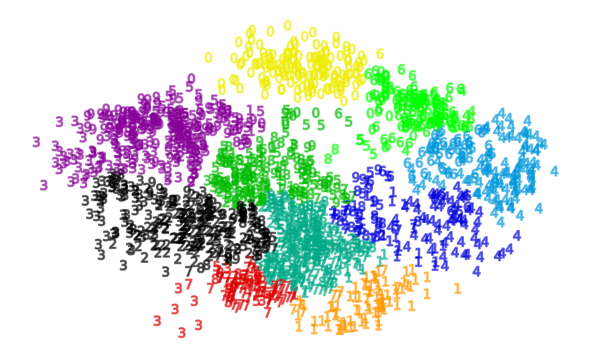

In [4]:
clt = AgglomerativeClustering(n_clusters=10)
clt.fit(X_red)
plot_clustering(X_red, clt.labels_)

### Top-Down

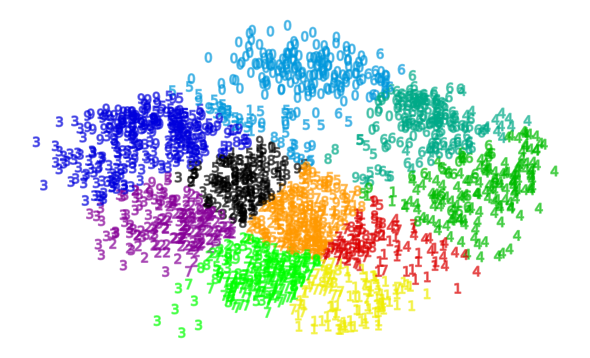

In [5]:
clt = BisectingKMeans(n_clusters=10, random_state=0)
clt.fit(X_red)
plot_clustering(X_red, clt.labels_)

## Linkage: Single

### 2D PCA

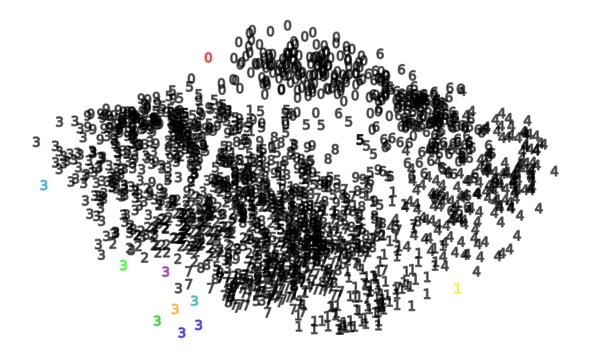

In [6]:
clt = AgglomerativeClustering(n_clusters=10, linkage='single')
clt.fit(X_red)
plot_clustering(X_red, clt.labels_)

### Dendrogram

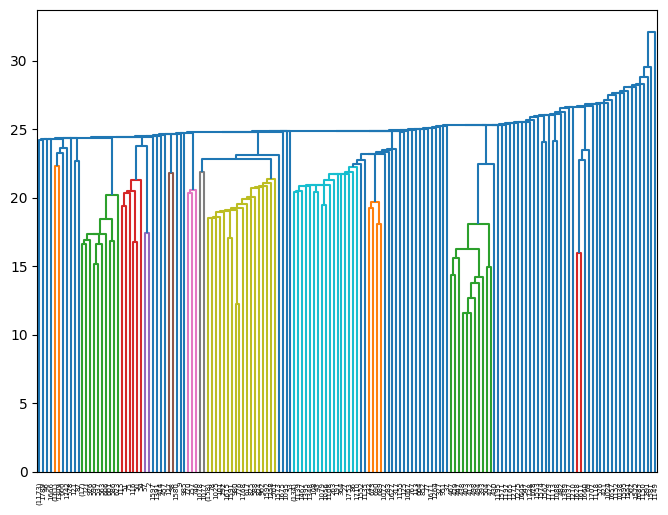

In [7]:
links = linkage(X, 'single')

plt.figure(figsize=(8, 6))
dendrogram(links, orientation='top', truncate_mode="level", distance_sort='descending',
           show_leaf_counts=True, p=70)
plt.show()

## Linkage: Complete

### 2D PCA

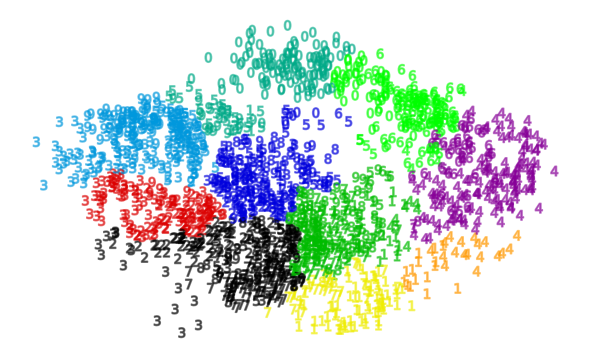

In [8]:
clt = AgglomerativeClustering(n_clusters=10, linkage='complete')
clt.fit(X_red)
plot_clustering(X_red, clt.labels_)

### Dendrogram

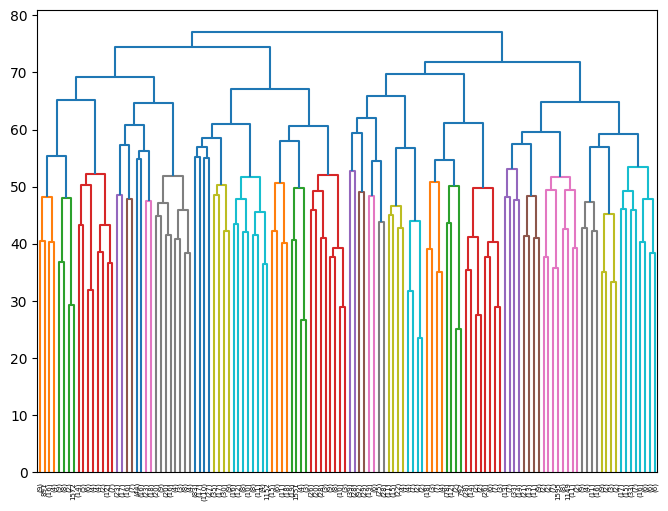

In [9]:
links = linkage(X, 'complete')

plt.figure(figsize=(8, 6))
dendrogram(links, orientation='top', truncate_mode="level", distance_sort='descending',
           show_leaf_counts=True, p=6)
plt.show()

## Linkage: Average

### 2D PCA

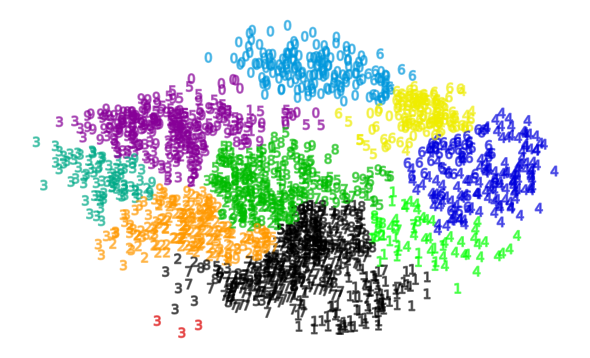

In [10]:
clt = AgglomerativeClustering(n_clusters=10, linkage='average')
clt.fit(X_red)
plot_clustering(X_red, clt.labels_)

### Dendrogram

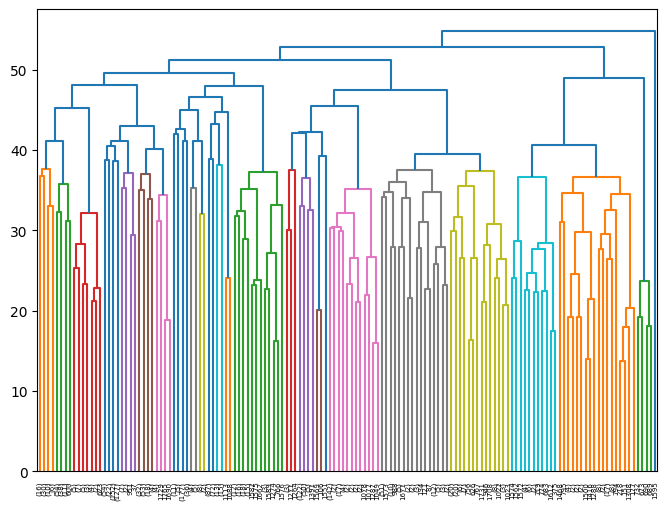

In [11]:
links = linkage(X, 'average')

plt.figure(figsize=(8, 6))
dendrogram(links, orientation='top', truncate_mode="level", distance_sort='descending',
           show_leaf_counts=True, p=8)
plt.show()

## Linkage: Ward

### 2D PCA

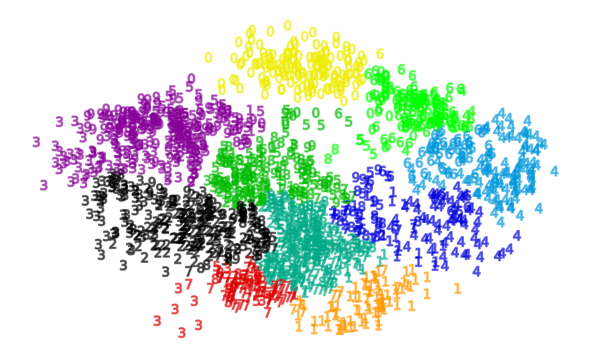

In [12]:
clt = AgglomerativeClustering(n_clusters=10, linkage='ward')
clt.fit(X_red)
plot_clustering(X_red, clt.labels_)

### Dendrogram

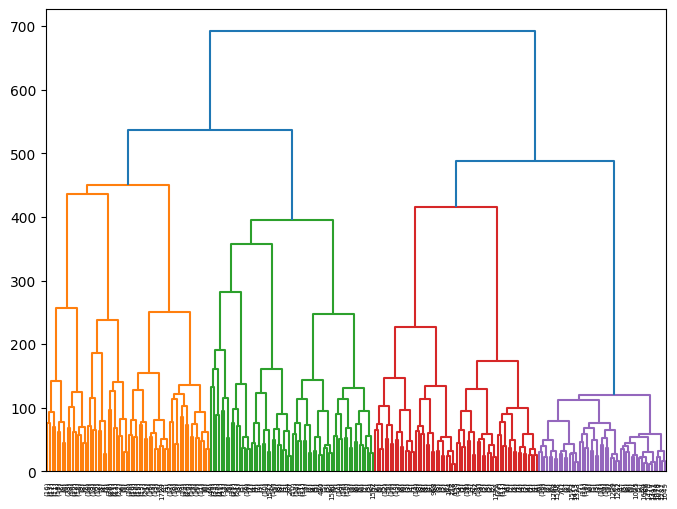

In [13]:
links = linkage(X, 'ward')

plt.figure(figsize=(8, 6))
dendrogram(links, orientation='top', truncate_mode="level", distance_sort='descending',
           show_leaf_counts=True, p=7)
plt.show()